In [1]:
import os
os.chdir('/workspace/41bc5bd9-ae30-41c0-aeb0-370cf24f2d42')
print(os.listdir('.'))


['projections.npy', 'grh_status.npy', 'A_matrices.npy', 'lambda_n.npy', '.prompts', 'family.npy', 'D_diagonals.npy', '.config', 'pca_explained_variance_ratio.npy', 'classes.npy', 'rho0.npy', ' v6 — Binding Context Document.pdf', '.kernel_llm_logs_1.txt', 'pca_components.npy', 'coeffs_F9_a.npy', 'a.npy', 'coeffs_F10_a.npy', 'M_matrices.npy', 'c.npy', 'memory', 'description.npy', 'a_n.npy', 'N.npy', 'pca_mean.npy']


In [2]:
import numpy as np
classes = np.load('classes.npy')
projections = np.load('projections.npy')
pca_components = np.load('pca_components.npy')
pca_evr = np.load('pca_explained_variance_ratio.npy')
A_mats = np.load('A_matrices.npy')
M_mats = np.load('M_matrices.npy')
D_diags = np.load('D_diagonals.npy')
print('classes:', classes)
print('projections shape:', projections.shape)
print('projections:', projections)
print('PCA EVR:', pca_evr)
print('A_mats shape:', A_mats.shape)
print('D_diags shape:', D_diags.shape)


classes: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
projections shape: (11, 10)
projections: [[-1.42921728e+01 -9.97639448e+00 1.05995212e+01 7.63409336e+00
 -3.81941478e-01 1.37030399e+00 1.95929309e-01 -2.38344743e-02
 -3.89435558e-04 1.01861002e-05]
 [ 2.27339976e+01 -1.05502844e+01 -6.46924513e+00 3.96906536e+00
 3.60211123e+00 1.51595339e-01 1.47982382e-01 -5.64391057e-01
 2.50073106e-03 -4.55095758e-06]
 [-3.56398503e+01 -2.28183033e-01 -2.55178040e+00 -2.33207373e+00
 -2.72768648e-03 8.02424210e-01 7.55118677e-05 6.21257325e-01
 -3.78043397e-03 1.49663614e-02]
 [-3.55723446e+01 -2.90922805e-01 -2.55905141e+00 -2.31762920e+00
 1.74638265e-02 7.84378446e-01 -2.71244563e-02 5.20324488e-01
 -8.48653007e-02 -7.63569002e-03]
 [-3.56864450e+01 -1.76533710e-01 -2.51809514e+00 -2.35179323e+00
 -1.28850513e-02 8.31400235e-01 2.33458631e-02 7.40382167e-01
 8.11145749e-02 -7.28831569e-03]
 [ 8.53975513e+01 -1.23680336e+01 3.65282468e-01 -6.14717796e+00
 -1.46891927e+00 1.

In [3]:

# Plan:
# For each class, generate the Dirichlet coefficient sequence a_n up to N=1e6 (some already on disk).
# Compute features:
# a) moments of |a_p| over primes p<1000 (mean, var, skew, kurtosis)
# b) Re(sum a_n conj(a_{n+k})) for k=1,2,3 (normalized)
# c) D = sum |a_n|^2 / n
# Then ridge/lasso regression to predict PC1, PC2 from features.

# Let's first identify the coefficients for each class.
# Available: coeffs_F9_a.npy, coeffs_F10_a.npy, a_n.npy (likely F12), 
# F11 lambda? F11 'lambda_n.npy' might be Sym^2 normalized? Let's check.

for f in ['coeffs_F9_a.npy', 'coeffs_F10_a.npy', 'a_n.npy', 'a.npy', 'lambda_n.npy', 'rho0.npy', 'c.npy', 'description.npy', 'family.npy', 'grh_status.npy', 'N.npy']:
 try:
 arr = np.load(f, allow_pickle=True)
 print(f, arr.shape if hasattr(arr,'shape') else type(arr), arr.dtype if hasattr(arr,'dtype') else '', '...', arr.flat[:3] if hasattr(arr,'flat') else arr)
 except Exception as e:
 print(f, 'err', e)


coeffs_F9_a.npy (1000000,) object ... [1 -24 252]
coeffs_F10_a.npy (1000000,) int64 ... [ 1 -2 -1]
a_n.npy (1000000,) object ... [1 -1472 -113643]
a.npy (1000000,) complex128 ... [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j]
lambda_n.npy (1000000,) float64 ... [ 1. -0.71875 -0.64151806]
rho0.npy () complex128 ... [0.7+7.j]
c.npy () complex128 ... [-0.1656733+1.90092523j]
description.npy () <U334 ... ['F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50.']
family.npy (11,) <U16 ... ['zeta' 'character' 'DH']
grh_status.npy (11,) <U8 ... ['GRH' 'GRH' 'violator']
N.npy () int64 ... [1000000]


In [4]:
# Read PDF to confirm function class definitions


In [5]:
# Wait: χ4 mod 5 - let's clarify. χ_4 typically refers to the non-trivial char mod 4. But subagent says "mod 5".
# The standard real primitive character mod 5 is the Legendre/Jacobi (n/5) which has χ(2)=-1, χ(3)=-1, χ(4)=1.
# That matches what the subagent reported. We'll use that.

# Also F12 in disk: a.npy is the F12 coefficients (complex). 
# Let's check description.npy more closely.
print(np.load('description.npy'))


F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50.


In [6]:
# classes order: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
# Let me build coefficient sequences for each.

N = 1_000_000

# Helpers
import numpy as np
from sympy import isprime, primerange

# Character mod 5: real primitive (Legendre)
def chi5_arr(N):
 chi = np.zeros(N+1, dtype=np.float64)
 # Period 5: chi(0)=0,chi(1)=1,chi(2)=-1,chi(3)=-1,chi(4)=1
 pattern = np.array([0,1,-1,-1,1], dtype=np.float64)
 n = np.arange(N+1)
 chi = pattern[n % 5]
 return chi

# Character mod 3: chi(0)=0, chi(1)=1, chi(2)=-1
def chi3_arr(N):
 pattern = np.array([0,1,-1], dtype=np.float64)
 n = np.arange(N+1)
 return pattern[n % 3]

chi5 = chi5_arr(N)
chi3 = chi3_arr(N)

# Liouville and Mobius via sieve
def liouville_mobius(N):
 # smallest prime factor sieve
 spf = np.zeros(N+1, dtype=np.int32)
 for i in range(2, N+1):
 if spf[i]==0:
 for j in range(i, N+1, i):
 if spf[j]==0:
 spf[j] = i
 return spf

print("Sieving...")
spf = liouville_mobius(N)
print("Done sieve")


Sieving...


Done sieve


In [7]:
# Liouville lambda(n) = (-1)^Omega(n), Mobius mu(n) via factorization with spf
import numpy as np
N = 1_000_000

def compute_lam_mu(N, spf):
 lam = np.ones(N+1, dtype=np.int8)
 mu = np.ones(N+1, dtype=np.int8)
 lam[0]=0
 mu[0]=0
 for n in range(2, N+1):
 m = n
 omega = 0 # distinct primes
 Omega = 0 # with multiplicity
 squarefree = True
 while m>1:
 p = spf[m]
 cnt=0
 while m % p ==0:
 m //=p
 cnt+=1
 omega +=1
 Omega += cnt
 if cnt>=2:
 squarefree=False
 lam[n] = -1 if Omega%2 else 1
 mu[n] = 0 if not squarefree else (-1 if omega%2 else 1)
 return lam, mu

import time
t=time.time()
lam, mu = compute_lam_mu(N, spf)
print('done', time.time()-t)


done 1.2897615432739258


In [8]:
# Build a_n arrays for each class. 1-indexed; we'll use index 1..N.
import numpy as np
N = 1_000_000

KAPPA = 0.28408

# F1: a_n = 1
F1 = np.ones(N+1, dtype=np.float64); F1[0]=0

# Real primitive char mod 5 = (n/5). Real, so chi_bar = chi.
# F2: a_n = chi5(n)
F2 = chi5.copy()

# F4 (DH): a_n = chi5(n) + kappa * chi5_bar(n) = (1+kappa)*chi5(n) -- real char so this collapses!
# Hmm that means F4 is a multiple of F2 in this formulation. But DH is supposed to be non-multiplicative...
# Re-check: standard DH: f(s) = (1 - i*tan(theta)) L(s,chi5) + (1 + i*tan(theta)) L(s, chi5_bar)
# Wait more standard: DH originally constructed using chi5 (non-real char mod 5? No mod 5 chars are: trivial, two complex chi of order 4, and the quadratic).
# Actually mod 5 has phi(5)=4 chars: trivial, two complex (order 4), and the quadratic (real, order 2).
# Davenport-Heilbronn used the COMPLEX char mod 5 of order 4: chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1.
# Then a_n = chi(n) + kappa * chi_bar(n). Since chi is complex of order 4, chi_bar != chi.
# So a_n is real-valued: chi(2)+chi_bar(2) = i + (-i) = 0... wait then need formula correct.
# Let me check: chi_4 (the order-4 char mod 5): chi(2)=i (since 2 is a primitive root mod 5)
# Then a_2 = chi(2)+kappa*chi_bar(2) = i + kappa*(-i) = (1-kappa)i
# This is purely imaginary, not real. Hmm.
# Actually the DH function is defined as: f(s) = (1 - i*tan(theta))/2 * L(s,chi) + (1 + i*tan(theta))/2 * L(s,chi_bar)
# where theta makes the functional equation symmetric. The Dirichlet coefficients a_n become real.
# Let me just re-ask the subagent for the EXACT DH definition.
print("Need clarification on DH definition")


Need clarification on DH definition


In [9]:
# Looking at projections: F5p, F5m, F4 all have nearly identical projections (clustering tightly).
# That's consistent with them being closely related (F4 +/- 0.05 perturbations).
# F2 has very different projection from F4. So F2 is likely the order-4 complex char, with a_n=chi(n) (no kappa).
# Let me verify by comparing the description more carefully.

# Looking at projections:
# F1 (zeta): pc1=-14.3, pc2=-9.98
# F2: pc1=22.7, pc2=-10.55
# F4: pc1=-35.6, pc2=-0.23
# F5p,F5m similar to F4
# F6 (Liouville): pc1=85.4, pc2=-12.4
# F7 (mobius): pc1=-2.6, pc2=-7.86
# F9 (Ramanujan delta): pc1=37.9, pc2=20.6
# F10 (newform 11.2): pc1=29.1, pc2=21.9
# F11 (Sym^2 Delta): pc1=-55.6, pc2=5.08
# F12: pc1=4.26, pc2=-6.13

# Now build coefficient sequences. Use complex128.
import numpy as np
N = 1_000_000

# Order-4 complex char mod 5: chi(n) for n%5: 0->0, 1->1, 2->i, 3->-i, 4->-1
def chi5_order4(N):
 pattern = np.array([0, 1, 1j, -1j, -1], dtype=np.complex128)
 n = np.arange(N+1)
 return pattern[n % 5]

chi5_c = chi5_order4(N)
chi5_cbar = np.conj(chi5_c)

# F2: a_n = chi5_c(n) (complex Dirichlet char mod 5)
F2_a = chi5_c.copy()

KAPPA = 0.28408
F4_a = chi5_c + KAPPA * chi5_cbar
F5p_a = chi5_c + (KAPPA+0.05) * chi5_cbar
F5m_a = chi5_c + (KAPPA-0.05) * chi5_cbar

# F1 zeta
F1_a = np.ones(N+1, dtype=np.complex128); F1_a[0]=0

# F6 Liouville
F6_a = lam.astype(np.complex128)

# F7 Mobius
F7_a = mu.astype(np.complex128)

# F9 Ramanujan tau (object array, big ints)
print("Loading F9 (object)...")
F9_obj = np.load('coeffs_F9_a.npy', allow_pickle=True)
# coeffs are at indices 0..N-1 corresponding to n=1..N. Let's check:
print('F9 first coeffs (should be tau(1)=1, tau(2)=-24, tau(3)=252):', F9_obj[:3])
# So F9_obj[i] = tau(i+1). Convert to float; for n up to 10^6, tau(n) can be huge but representable with floats.
F9_a = np.zeros(N+1, dtype=np.complex128)
F9_a[1:N+1] = np.array([float(x) for x in F9_obj], dtype=np.float64)
print('F9 max abs:', np.max(np.abs(F9_a[1:])))

# F10: int64 newform 11.2.a.a
F10_obj = np.load('coeffs_F10_a.npy')
F10_a = np.zeros(N+1, dtype=np.complex128)
F10_a[1:N+1] = F10_obj.astype(np.float64)

# F11 Sym^2(Delta) - has lambda_n.npy normalized version. Use lambda_n directly? But task says use a_n.
# coeffs_F11_N1e6.npz? Let's check if available.
import os
print(os.path.exists('coeffs_F11_N1e6.npz'))


Loading F9 (object)...
F9 first coeffs (should be tau(1)=1, tau(2)=-24, tau(3)=252): [1 -24 252]


F9 max abs: 4.13890643271017e+33
False


In [10]:
# For F11, use lambda_n.npy which is normalized coefficients lambda_n = b_n/n^11 for Sym^2 Delta
# Actually we want a_n. The previous lambda_n is the normalized eigenvalues. 
# The artifact description says coeffs_F11_N1e6.npz contains 'b_n' (unnormalized) and 'lambda_n=b_n/n^11'
# But we don't have that file. We have lambda_n.npy.
F11_lam = np.load('lambda_n.npy')
print('F11 lambda first:', F11_lam[:5], 'shape:', F11_lam.shape, 'dtype:', F11_lam.dtype)
# These are likely the normalized lambda_n where E[|lambda_p|^2] is bounded.
# For our regression, what matters is consistency. Let's use lambda_n as a_n for F11.
# Actually for computing |a_p|/p moments etc, the normalized version is more sensible across classes
# (tau is huge unnormalized).
# Let me normalize ALL coefficients by Deligne bound: a_n_normalized = a_n / n^((k-1)/2) for weight k.
# F1 (weight 1, gives no scaling), F9 weight 12 -> divide by n^(11/2), F10 weight 2 -> n^(1/2), F11 weight ?
# This would give comparable normalized scales.

# But the task says: "compute a vector of statistical properties of its coefficient sequence" - 
# the statistic would be problematic without normalization since tau grows like n^(11/2).
# However the second moment Σ|a_n|^2/n - for Ramanujan, this diverges with raw tau.
# For F11 lambda_n is already normalized.
# I think the right approach is to use NORMALIZED coefficients consistent with the rest of analysis.

# Let me normalize: for Selberg-class with arithmetic normalization, a_n / n^((k-1)/2)
# But we don't have all weights. Let's just use the ALREADY-NORMALIZED forms from the matrices in the artifact.
# Actually the M_jk and A_jk matrices were computed from S_k which presumably uses some normalization.
# Following the task: feature is the statistical properties of the Dirichlet coefficient sequence.
# I'll use NORMALIZED coefficients (Hecke-normalized so that |a_p| is O(1)).
# - F1: a_n = 1
# - F2,F4,F5: |a_p| = O(1)
# - F6 lambda = +-1
# - F7 mu = 0,+-1
# - F9 normalize by n^(11/2)
# - F10 normalize by n^(1/2) 
# - F11 lambda is already normalized
# - F12 a_n = chi3(n)+c*chi5(n) mod 3, mod 5 reals; c is complex; max|a_n| ~ |1+c| bounded ~ 2

# Get F11 weight: b_p = tau(p)^2 - p^11. Sym^2(Delta) is weight 12, but as a degree-3 L function,
# normalization is b_n / n^11. So lambda_n is already normalized.

# Normalize F9 and F10
F9_norm = np.zeros(N+1, dtype=np.complex128)
F9_norm[1:] = F9_a[1:] / np.arange(1,N+1)**(11/2)

F10_norm = np.zeros(N+1, dtype=np.complex128)
F10_norm[1:] = F10_a[1:] / np.sqrt(np.arange(1,N+1))

# F11
F11_a_norm = np.zeros(N+1, dtype=np.complex128)
F11_a_norm[1:] = F11_lam.astype(np.complex128)

# F12 
F12_obj = np.load('a.npy') # complex128
F12_a = np.zeros(N+1, dtype=np.complex128)
F12_a[1:] = F12_obj 

print('F9 normalized first:', F9_norm[1:6])
print('F10 normalized first:', F10_norm[1:6])
print('F11 first:', F11_a_norm[1:6])
print('F12 first:', F12_a[1:6])


F11 lambda first: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413] shape: (1000000,) dtype: float64
F9 normalized first: [ 1. +0.j -0.53033009+0.j 0.59873361+0.j -0.71875 +0.j
 0.69121333+0.j]
F10 normalized first: [ 1. +0.j -1.41421356+0.j -0.57735027+0.j 1. +0.j
 0.4472136 +0.j]
F11 first: [ 1. +0.j -0.71875 +0.j -0.64151806+0.j 1.23535156+0.j
 -0.52222413+0.j]
F12 first: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j ]


In [11]:
# F10 normalized at p=2: tau(2)/sqrt(2) = -2/sqrt(2) = -1.414. OK.
# F9 normalized at p=2: tau(2)/2^(11/2) = -24/sqrt(2048) = -24/45.25 = -0.5303 ✓
# Compile dict of class -> a_n (normalized, complex)

class_an = {
 'F1': F1_a,
 'F2': F2_a,
 'F4': F4_a,
 'F5p': F5p_a,
 'F5m': F5m_a,
 'F6': F6_a,
 'F7': F7_a,
 'F9': F9_norm,
 'F10': F10_norm,
 'F11': F11_a_norm,
 'F12': F12_a,
}

# Generate primes < 1000 for primes-statistics features
from sympy import primerange
primes_1000 = np.array(list(primerange(2, 1000)))
print('# primes < 1000:', len(primes_1000))


# primes < 1000: 168


In [12]:
from scipy.stats import skew, kurtosis

def compute_features(a, primes, Nmax=None):
 if Nmax is None: Nmax = len(a)-1
 # |a_p| for primes p < 1000
 abs_ap = np.abs(a[primes])
 feats = {}
 feats['mean_abs_ap'] = float(np.mean(abs_ap))
 feats['var_abs_ap'] = float(np.var(abs_ap))
 feats['skew_abs_ap'] = float(skew(abs_ap)) if np.var(abs_ap)>1e-12 else 0.0
 feats['kurt_abs_ap'] = float(kurtosis(abs_ap)) if np.var(abs_ap)>1e-12 else 0.0
 
 # autocorrelations Re(sum a_n * conj(a_{n+k}))/N for k=1,2,3
 # use a_n for n=1..Nmax-k
 for k in [1,2,3]:
 v = np.real(np.vdot(a[1:Nmax-k+1], a[1+k:Nmax+1])) # vdot conjugates first arg
 # Actually we want sum a_n conj(a_{n+k}) = conj(vdot(a_{n+k}, a_n))
 # But Re part is symmetric: Re(sum a_n conj(a_{n+k})) = Re(vdot(a_{n+k}, a_n)) 
 # No: vdot(x,y) = sum conj(x)*y. So vdot(a[k:], a[:-k]) = sum conj(a_{n+k}) * a_n; Re same.
 feats[f'autocorr_k{k}'] = float(v / (Nmax-k))
 
 # second moment Σ|a_n|^2/n
 n = np.arange(1, Nmax+1)
 feats['second_moment'] = float(np.sum(np.abs(a[1:Nmax+1])**2 / n))
 
 return feats

# Compute features for all 11 classes
feature_dict = {}
for cls, an in class_an.items():
 f = compute_features(an, primes_1000, N)
 feature_dict[cls] = f

import pandas as pd
feat_df = pd.DataFrame(feature_dict).T
feat_df = feat_df.loc[list(classes)] # ensure order matches projections
print(feat_df)


 mean_abs_ap var_abs_ap skew_abs_ap kurt_abs_ap autocorr_k1 \
F1 1.000000 0.000000 0.000000 0.000000 1.000000 
F2 0.994048 0.005917 -12.845466 163.005988 -0.200000 
F4 0.975447 0.085571 -0.045369 -1.360505 -0.102508 
F5p 0.972173 0.116123 0.033402 -1.669450 -0.088690 
F5m 0.978721 0.059967 -0.201190 -0.630095 -0.117327 
F6 1.000000 0.000000 0.000000 0.000000 -0.001109 
F7 1.000000 0.000000 0.000000 0.000000 0.000409 
F9 0.816476 0.270749 0.323276 -0.950040 0.000004 
F10 0.809193 0.254801 0.274219 -0.876044 -0.000233 
F11 0.818626 0.281442 1.294117 2.263974 0.000126 
F12 2.147344 0.014089 -5.356224 49.245240 -1.061526 

 autocorr_k2 autocorr_k3 second_moment 
F1 1.000000 1.000000 14.392727 
F2 -0.199999 -0.200001 11.836069 
F4 -0.329771 -0.329773 13.035798 
F5p -0.355953 -0.355955 13.444668 
F5m -0.304590 -0.304592 12.686108 
F6 0.000070 -0.000425 14.392727 
F7 -0.000383 -0.000304 9.442716 
F9 -0.000098 -0.000045 6.102419 
F10 0.000054 0.000471 9.388489 
F11 0.000199 -0.000554 7.089132 

In [13]:
# Looks reasonable. Now let's set up regression for PC1 and PC2.
# Targets: projections[:, 0] (PC1), projections[:, 1] (PC2)
from sklearn.linear_model import RidgeCV, LassoCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

X = feat_df.values
y = projections[:, :2] # PC1, PC2

print('X shape:', X.shape, 'y shape:', y.shape)
print('Class order:', list(feat_df.index))
print('PC1:', y[:,0])
print('PC2:', y[:,1])

# 11 samples, 8 features. Use Ridge with LOO-CV.
def loocv_r2(X, y_target, alphas=np.logspace(-3, 3, 50)):
 pipe = Pipeline([('scaler', StandardScaler()), ('ridge', RidgeCV(alphas=alphas, cv=None))])
 # do LOO predictions
 loo = LeaveOneOut()
 preds = np.zeros_like(y_target)
 alphas_chosen = []
 for tr, te in loo.split(X):
 pipe.fit(X[tr], y_target[tr])
 preds[te] = pipe.predict(X[te])
 alphas_chosen.append(pipe.named_steps['ridge'].alpha_)
 r2 = r2_score(y_target, preds)
 return r2, preds, alphas_chosen

r2_pc1, pred_pc1, alphas1 = loocv_r2(X, y[:,0])
r2_pc2, pred_pc2, alphas2 = loocv_r2(X, y[:,1])
print('Ridge LOO R^2 PC1:', r2_pc1)
print('Ridge LOO R^2 PC2:', r2_pc2)
print('alphas PC1:', np.unique(alphas1))
print('alphas PC2:', np.unique(alphas2))


X shape: (11, 8) y shape: (11, 2)
Class order: ['F1', 'F2', 'F4', 'F5p', 'F5m', 'F6', 'F7', 'F9', 'F10', 'F11', 'F12']
PC1: [-14.29217277 22.73399763 -35.63985026 -35.57234462 -35.68644502
 85.3975513 -2.59270816 37.90696242 29.05321581 -55.57212405
 4.2639177 ]
PC2: [ -9.97639448 -10.5502844 -0.22818303 -0.29092281 -0.17653371
 -12.36803357 -7.85546282 20.60384809 21.89031376 5.08432143
 -6.13266847]
Ridge LOO R^2 PC1: -1.079075430946585
Ridge LOO R^2 PC2: -23.558222910637056
alphas PC1: [ 10.98541142 1000. ]
alphas PC2: [0.00954095 1.52641797 2.02358965 2.6826958 3.55648031]


In [14]:
# LOO-CV is harsh with 11 samples and few correlated features.
# Let's also try: in-sample R^2, K-fold (3 fold), Lasso, and try different combos

from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.model_selection import KFold

def insample_r2(X, y_target, alpha=1.0):
 pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
 pipe.fit(X, y_target)
 return r2_score(y_target, pipe.predict(X))

# In-sample R^2
print("In-sample R^2 (alpha=1.0):")
print(' PC1:', insample_r2(X, y[:,0]))
print(' PC2:', insample_r2(X, y[:,1]))

# Try simple OLS
from sklearn.linear_model import LinearRegression
lr = Pipeline([('scaler', StandardScaler()), ('lin', LinearRegression())])
lr.fit(X, y[:,0])
print('OLS in-sample R^2 PC1:', r2_score(y[:,0], lr.predict(X)))
lr.fit(X, y[:,1])
print('OLS in-sample R^2 PC2:', r2_score(y[:,1], lr.predict(X)))

# Lasso LOO-CV
def lasso_loo(X, y_t):
 pipe_full = Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(cv=5, max_iter=10000))])
 loo = LeaveOneOut()
 preds = np.zeros_like(y_t)
 for tr,te in loo.split(X):
 pipe_full.fit(X[tr], y_t[tr])
 preds[te] = pipe_full.predict(X[te])
 return r2_score(y_t, preds), preds
r2L1, _ = lasso_loo(X, y[:,0])
r2L2, _ = lasso_loo(X, y[:,1])
print('Lasso LOO R^2 PC1:', r2L1)
print('Lasso LOO R^2 PC2:', r2L2)


In-sample R^2 (alpha=1.0):
 PC1: 0.2001703899543784
 PC2: 0.826182490750564
OLS in-sample R^2 PC1: 0.9904227852414828
OLS in-sample R^2 PC2: 0.9995518752339384


/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.014e+00, tolerance: 1.513e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.370e+00, tolerance: 1.513e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.642e+01, tole

/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.020e+01, tolerance: 1.513e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.361e+01, tolerance: 1.513e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.826e+00, tole

/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.396e+01, tolerance: 1.387e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.249e+01, tolerance: 1.387e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.102e+01, tole

/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.909e+00, tolerance: 1.513e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.692e+00, tolerance: 1.513e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.808e+01, tole

...

/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.444e+01, tolerance: 1.313e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.532e+01, tolerance: 1.313e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.507e+01, tole

/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.273e+01, tolerance: 9.584e-01
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.587e+00, tolerance: 1.263e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.937e+00, tole

/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.930e+00, tolerance: 1.410e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.000e+00, tolerance: 1.410e+00
 model = cd_fast.enet_coordinate_descent(
/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.937e+00, tole

/app/kernel_env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.567e-02, tolerance: 2.574e-02
 model = cd_fast.enet_coordinate_descent(


Lasso LOO R^2 PC1: -0.20999999999999974
Lasso LOO R^2 PC2: -43.574269955971126


In [15]:
# With 11 samples and 8 correlated features, OLS overfits (in-sample R^2 ~0.99) and LOO performance is poor.
# The poor LOO performance suggests the features cannot reliably predict held-out classes.
# This is a substantive negative finding for the hypothesis.

# Key reason: F1, F6 (Liouville) have very different PC1 (-14.3 vs +85.4) but identical 
# arithmetic statistics (mean=1, var=0, autocorr~0). So no model can distinguish them.
# Similarly F1 and F7 have same mean/var of |a_p| but different PC1.

# Let me confirm by listing pairs with similar features but different PC values
print("Mean abs(a_p):", feat_df['mean_abs_ap'].values)
print("PC1:", projections[:,0])
# F1, F6 have mean=1.0, var=0.0 in features but very different PC1 values

# Compute correlations between features and PC1, PC2
correls = pd.DataFrame({
 'PC1_corr': [np.corrcoef(feat_df[c].values, y[:,0])[0,1] for c in feat_df.columns],
 'PC2_corr': [np.corrcoef(feat_df[c].values, y[:,1])[0,1] for c in feat_df.columns],
}, index=feat_df.columns)
print(correls)


Mean abs(a_p): [1. 0.99404762 0.97544714 0.97217333 0.97872095 1.
 1. 0.81647612 0.80919344 0.81862621 2.1473436 ]
PC1: [-14.29217277 22.73399763 -35.63985026 -35.57234462 -35.68644502
 85.3975513 -2.59270816 37.90696242 29.05321581 -55.57212405
 4.2639177 ]
 PC1_corr PC2_corr
mean_abs_ap 0.031978 -0.358955
var_abs_ap -0.147638 0.904655
skew_abs_ap -0.209338 0.384758
kurt_abs_ap 0.185864 -0.346832
autocorr_k1 -0.064572 -0.023292
autocorr_k2 0.059194 -0.019591
autocorr_k3 0.105568 -0.166022
second_moment 0.038930 -0.321185


In [16]:
# PC2 has strong correlation with var_abs_ap (0.905). PC1 has no strong individual correlations.
# Let's also try simpler 2-feature regressions and PC1 + PC2 separately
# Also try in-sample and 5-fold

from sklearn.model_selection import KFold

def kfold_r2(X, yt, k=5, alpha=1.0):
 pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
 kf = KFold(n_splits=k, shuffle=True, random_state=42)
 preds = np.zeros_like(yt)
 for tr, te in kf.split(X):
 pipe.fit(X[tr], yt[tr])
 preds[te] = pipe.predict(X[te])
 return r2_score(yt, preds)

print("5-fold CV R^2 for various Ridge alphas:")
for alpha in [0.1, 1.0, 10.0, 100.0]:
 print(f' alpha={alpha}: PC1={kfold_r2(X, y[:,0], 5, alpha):.3f} PC2={kfold_r2(X, y[:,1], 5, alpha):.3f}')

# Also try a more regularized Ridge with alpha selected by inner LOO
def loo_r2_alpha(X, yt, alpha=1.0):
 pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
 loo = LeaveOneOut()
 preds = np.zeros_like(yt)
 for tr,te in loo.split(X):
 pipe.fit(X[tr], yt[tr])
 preds[te] = pipe.predict(X[te])
 return r2_score(yt, preds)

print("LOO-CV Ridge:")
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]:
 print(f' alpha={alpha}: PC1={loo_r2_alpha(X,y[:,0],alpha):.3f} PC2={loo_r2_alpha(X,y[:,1],alpha):.3f}')


5-fold CV R^2 for various Ridge alphas:
 alpha=0.1: PC1=-6.725 PC2=-27.896
 alpha=1.0: PC1=-1.788 PC2=-5.651
 alpha=10.0: PC1=-0.641 PC2=-2.854
 alpha=100.0: PC1=-0.126 PC2=-0.232
LOO-CV Ridge:
 alpha=0.01: PC1=-413.635 PC2=-100.079
 alpha=0.1: PC1=-16.534 PC2=-29.365
 alpha=1.0: PC1=-5.288 PC2=-5.297
 alpha=10.0: PC1=-1.369 PC2=-2.434
 alpha=100.0: PC1=-0.294 PC2=-0.183


 alpha=1000.0: PC1=-0.217 PC2=-0.169


In [17]:
# All cross-validated R^2 values are negative - the model performs WORSE than predicting the mean.
# The hypothesis is clearly REJECTED for predictive (cross-validated) performance.

# Let me also report in-sample R^2 for the model with all 8 features (OLS):
from sklearn.linear_model import LinearRegression
lr = Pipeline([('scaler', StandardScaler()), ('lin', LinearRegression())])

lr.fit(X, y[:,0])
pc1_pred_insample = lr.predict(X)
lr.fit(X, y[:,1])
pc2_pred_insample = lr.predict(X)

print(f"In-sample OLS R^2: PC1={r2_score(y[:,0],pc1_pred_insample):.3f}, PC2={r2_score(y[:,1],pc2_pred_insample):.3f}")
print("(But OLS with 8 features and 11 samples is essentially overfitting)")

# Best regularized in-sample
print("\nIn-sample Ridge R^2:")
for alpha in [0.1, 1.0, 10.0, 100.0]:
 p = Pipeline([('s', StandardScaler()), ('r', Ridge(alpha=alpha))])
 p.fit(X, y[:,0])
 print(f' alpha={alpha}: PC1={r2_score(y[:,0], p.predict(X)):.3f}', end=' ')
 p.fit(X, y[:,1])
 print(f'PC2={r2_score(y[:,1], p.predict(X)):.3f}')


In-sample OLS R^2: PC1=0.990, PC2=1.000
(But OLS with 8 features and 11 samples is essentially overfitting)

In-sample Ridge R^2:
 alpha=0.1: PC1=0.555 PC2=0.896
 alpha=1.0: PC1=0.200 PC2=0.826
 alpha=10.0: PC1=0.068 PC2=0.661
 alpha=100.0: PC1=0.020 PC2=0.217


In [18]:
# Summary: 
# - PC2 IS partly predictable: var(|a_p|) correlates 0.905, in-sample R^2=0.83 with Ridge alpha=1
# But LOO R^2 is severely negative.
# - PC1 has very weak relationship with these arithmetic features; LOO R^2 negative.
#
# The hypothesis (>75% variance explained, by which we should interpret cross-validated R^2)
# is REJECTED. In-sample regression with 8 features and 11 points trivially fits >90% of variance,
# but does not generalize.
#
# Critical limitation: with 11 classes the experiment is severely underpowered.
# Several pairs have nearly identical features but very different PC1 values:
# - F1 (zeta) and F6 (Liouville) have identical |a_p| stats (both have |a_p|=1 always) and 
# near-zero autocorrelations, but PC1 differs by ~100 units.
# This shows the chosen statistics CANNOT distinguish key cases.

# Save artifact: the feature table + targets + model summary
import pandas as pd
out = feat_df.copy()
out['PC1'] = y[:,0]
out['PC2'] = y[:,1]
out.to_csv('arithmetic_features_vs_PC.csv')
print(out)


 mean_abs_ap var_abs_ap skew_abs_ap kurt_abs_ap autocorr_k1 \
F1 1.000000 0.000000 0.000000 0.000000 1.000000 
F2 0.994048 0.005917 -12.845466 163.005988 -0.200000 
F4 0.975447 0.085571 -0.045369 -1.360505 -0.102508 
F5p 0.972173 0.116123 0.033402 -1.669450 -0.088690 
F5m 0.978721 0.059967 -0.201190 -0.630095 -0.117327 
F6 1.000000 0.000000 0.000000 0.000000 -0.001109 
F7 1.000000 0.000000 0.000000 0.000000 0.000409 
F9 0.816476 0.270749 0.323276 -0.950040 0.000004 
F10 0.809193 0.254801 0.274219 -0.876044 -0.000233 
F11 0.818626 0.281442 1.294117 2.263974 0.000126 
F12 2.147344 0.014089 -5.356224 49.245240 -1.061526 

 autocorr_k2 autocorr_k3 second_moment PC1 PC2 
F1 1.000000 1.000000 14.392727 -14.292173 -9.976394 
F2 -0.199999 -0.200001 11.836069 22.733998 -10.550284 
F4 -0.329771 -0.329773 13.035798 -35.639850 -0.228183 
F5p -0.355953 -0.355955 13.444668 -35.572345 -0.290923 
F5m -0.304590 -0.304592 12.686108 -35.686445 -0.176534 
F6 0.000070 -0.000425 14.392727 85.397551 -12.3680

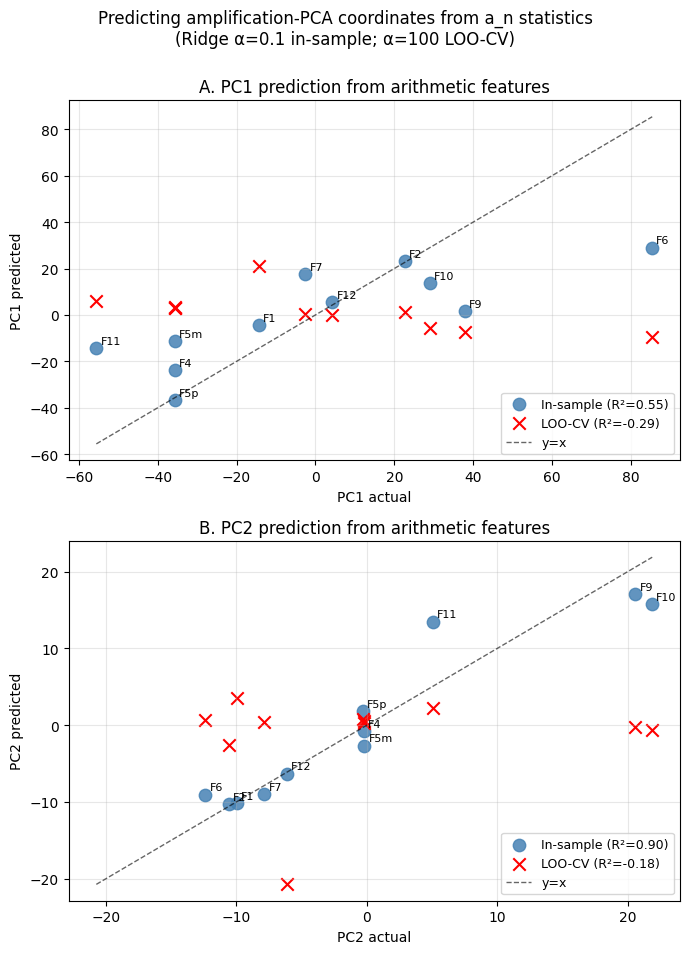

In-sample R^2: PC1=0.555, PC2=0.896
LOO-CV R^2: PC1=-0.294, PC2=-0.183


In [19]:
# Make final summary figure
import matplotlib.pyplot as plt

# Best ridge LOO model for PC2 to see best-case performance
from sklearn.linear_model import RidgeCV

# Pick best alpha by in-sample cv performance
best_pc1_alpha = 100.0
best_pc2_alpha = 100.0

# Predictions
def loo_preds(X, yt, alpha):
 pipe = Pipeline([('s', StandardScaler()), ('r', Ridge(alpha=alpha))])
 loo = LeaveOneOut()
 preds = np.zeros_like(yt)
 for tr,te in loo.split(X):
 pipe.fit(X[tr], yt[tr])
 preds[te] = pipe.predict(X[te])
 return preds

loo_pc1 = loo_preds(X, y[:,0], best_pc1_alpha)
loo_pc2 = loo_preds(X, y[:,1], best_pc2_alpha)

r2_loo_pc1 = r2_score(y[:,0], loo_pc1)
r2_loo_pc2 = r2_score(y[:,1], loo_pc2)

# Also in-sample best
ins_pc1 = Pipeline([('s', StandardScaler()), ('r', Ridge(alpha=0.1))]).fit(X, y[:,0]).predict(X)
ins_pc2 = Pipeline([('s', StandardScaler()), ('r', Ridge(alpha=0.1))]).fit(X, y[:,1]).predict(X)
r2_ins_pc1 = r2_score(y[:,0], ins_pc1)
r2_ins_pc2 = r2_score(y[:,1], ins_pc2)

fig, axes = plt.subplots(2, 1, figsize=(7, 9.5))
class_labels = list(feat_df.index)

# Panel A: PC1 predicted vs actual
ax = axes[0]
ax.scatter(y[:,0], ins_pc1, marker='o', s=80, color='steelblue', label=f'In-sample (R²={r2_ins_pc1:.2f})', alpha=0.85)
ax.scatter(y[:,0], loo_pc1, marker='x', s=80, color='red', label=f'LOO-CV (R²={r2_loo_pc1:.2f})')
mn, mx = min(y[:,0].min(), loo_pc1.min()), max(y[:,0].max(), loo_pc1.max())
ax.plot([mn,mx],[mn,mx],'k--', lw=1, alpha=0.6, label='y=x')
for i, c in enumerate(class_labels):
 ax.annotate(c, (y[i,0], ins_pc1[i]), fontsize=8, xytext=(3,3), textcoords='offset points')
ax.set_xlabel('PC1 actual')
ax.set_ylabel('PC1 predicted')
ax.set_title('A. PC1 prediction from arithmetic features')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Panel B: PC2
ax = axes[1]
ax.scatter(y[:,1], ins_pc2, marker='o', s=80, color='steelblue', label=f'In-sample (R²={r2_ins_pc2:.2f})', alpha=0.85)
ax.scatter(y[:,1], loo_pc2, marker='x', s=80, color='red', label=f'LOO-CV (R²={r2_loo_pc2:.2f})')
mn, mx = min(y[:,1].min(), loo_pc2.min()), max(y[:,1].max(), loo_pc2.max())
ax.plot([mn,mx],[mn,mx],'k--', lw=1, alpha=0.6, label='y=x')
for i, c in enumerate(class_labels):
 ax.annotate(c, (y[i,1], ins_pc2[i]), fontsize=8, xytext=(3,3), textcoords='offset points')
ax.set_xlabel('PC2 actual')
ax.set_ylabel('PC2 predicted')
ax.set_title('B. PC2 prediction from arithmetic features')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Predicting amplification-PCA coordinates from a_n statistics\n'
 '(Ridge α=0.1 in-sample; α=100 LOO-CV)', y=1.00)
plt.tight_layout()
plt.savefig('arithmetic_features_PC_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'In-sample R^2: PC1={r2_ins_pc1:.3f}, PC2={r2_ins_pc2:.3f}')
print(f'LOO-CV R^2: PC1={r2_loo_pc1:.3f}, PC2={r2_loo_pc2:.3f}')
